# Fichero `adult.csv` — Preparación de datos y modelo supervisado

Este notebook reúne **todo lo trabajado** hasta ahora:
1. Carga del dataset `adult.csv`
2. Creación del **dataset reducido** (solo columnas objetivo)
3. Limpieza de valores ausentes (`?` → `NaN`) y eliminación de filas incompletas
4. Definición de **X** e **y** (objetivo: `income`)
5. Identificación de variables **numéricas** y **categóricas**
6. Preprocesado con **ColumnTransformer** (StandardScaler + OneHotEncoder)
7. División **train/test**
8. Entrenamiento de un **modelo** (Regresión Logística)
9. Evaluación básica (classification report + matriz de confusión)



## 1. Carga del dataset

Nos aseguramos de que `adult.csv` está en la misma carpeta que este notebook.

In [143]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

df_adults = pd.read_csv('adult.csv')

df_adults.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


## 2. Creación del dataset reducido (solo columnas objetivo)
**Variables que se conservarán (las únicas permitidas en la práctica):**



In [144]:
#df_adults.drop(columns=['fnlwgt', 'education-num','marital.status', 'relationship','native.country'], inplace=True)

wished_columns = [
    'age', 'workclass', 'education', 'occupation', 'hours.per.week', 'income', 
    'race', 'sex','capital.gain', 'native.country', 'capital.loss'
]

df_model = df_adults[wished_columns].copy()

print(df_model.info())
print(df_model.shape)
df_model.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   education       32561 non-null  object
 3   occupation      32561 non-null  object
 4   hours.per.week  32561 non-null  int64 
 5   income          32561 non-null  object
 6   race            32561 non-null  object
 7   sex             32561 non-null  object
 8   capital.gain    32561 non-null  int64 
 9   native.country  32561 non-null  object
 10  capital.loss    32561 non-null  int64 
dtypes: int64(4), object(7)
memory usage: 2.7+ MB
None
(32561, 11)


,age,workclass,education,occupation,hours.per.week,income,race,sex,capital.gain,native.country,capital.loss
0,90,?,HS-grad,?,40,<=50K,White,Female,0,United-States,4356
1,82,Private,HS-grad,Exec-managerial,18,<=50K,White,Female,0,United-States,4356
2,66,?,Some-college,?,40,<=50K,Black,Female,0,United-States,4356
3,54,Private,7th-8th,Machine-op-inspct,40,<=50K,White,Female,0,United-States,3900
4,41,Private,Some-college,Prof-specialty,40,<=50K,White,Female,0,United-States,3900


## 3. Limpieza del dataset reducido

En adult.csv, los valores ausentes a veces aparecen como `?` en algunas columnas, como podemos ver en la celda anterior
- Sustituimos `?` por `NaN`
- Comprobamos nulos por columna


In [145]:
df_model.replace('?', np.nan, inplace=True)
df_model.dropna(inplace=True)
df_model.head()

,age,workclass,education,occupation,hours.per.week,income,race,sex,capital.gain,native.country,capital.loss
1,82,Private,HS-grad,Exec-managerial,18,<=50K,White,Female,0,United-States,4356
3,54,Private,7th-8th,Machine-op-inspct,40,<=50K,White,Female,0,United-States,3900
4,41,Private,Some-college,Prof-specialty,40,<=50K,White,Female,0,United-States,3900
5,34,Private,HS-grad,Other-service,45,<=50K,White,Female,0,United-States,3770
6,38,Private,10th,Adm-clerical,40,<=50K,White,Male,0,United-States,3770


## 4. Definir el problema supervisado: predicción de salario (`income`)

In [146]:
"""
Predecir si una persona gana mas de 50K al año en función de sus demás características.

Caso binario, solo hay 2 posibles valores: <=50K y >50K
"""

'\nPredecir si una persona gana mas de 50K al año en función de sus demás características.\n\nCaso binario, solo hay 2 posibles valores: <=50K y >50K\n'

## 5. Identificación de variables numéricas y categóricas

De lo anterior vemos que hay:
- variables numéricas: 
- variables categóricas:

In [147]:
"""
numericas: age, hours.per.week, capital.gain, capital.loss
categoricas: workclass, education, occupation, race, sex, native.country, income
"""

'\nnumericas: age, hours.per.week, capital.gain, capital.loss\ncategoricas: workclass, education, occupation, race, sex, native.country, income\n'

### Preprocesado de los datos

En esta fase se preparan las variables para su uso en el modelo de Machine Learning.
Dado que el conjunto de datos contiene variables numéricas y categóricas, se aplican
técnicas de preprocesado diferenciadas, incluyendo la imputación de valores nulos,
el escalado de variables numéricas y la codificación de variables categóricas mediante
One-Hot Encoding.


## 6. Preprocesado con sklearn

In [149]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

df_model['income'] = df_model['income'].replace({'<=50K':0, '>50K':1})

X = df_model.drop(columns='income', axis=1)
y = df_model['income']
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state = 16
)


Ahora terminamos de preparar todo

## 7. División en entrenamiento y prueba

### Entrenamiento del modelo

Una vez definidos el conjunto de entrenamiento y el preprocesado de los datos,
se procede al entrenamiento de un modelo de clasificación basado en regresión logística,
utilizado como modelo base para este problema.


In [150]:
"""model = LinearRegression()
model.fit(x_train, y_train)"""

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

"""
escalado = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())])

codificacion = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer()
"""

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train, y_train)


LogisticRegression()

## 8. Regresión


### Evaluación del modelo

El rendimiento del modelo se evalúa utilizando distintas métricas de clasificación,
así como la matriz de confusión, con el objetivo de analizar su capacidad predictiva
y detectar posibles limitaciones.


Accuracy: 0.8327531907840212
[[4290  277]
 [ 732  734]]
              precision    recall  f1-score   support

           0       0.85      0.94      0.89      4567
           1       0.73      0.50      0.59      1466

    accuracy                           0.83      6033
   macro avg       0.79      0.72      0.74      6033
weighted avg       0.82      0.83      0.82      6033



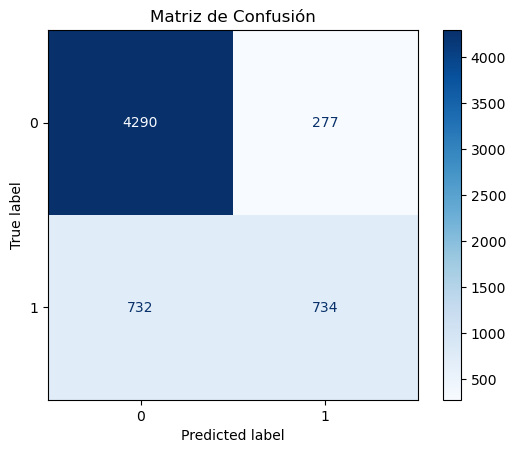

R2: 0.09079982710057999
MAE: 0.1672468092159788
MSE: 0.1672468092159788
CM:
 [[4290  277]
 [ 732  734]]


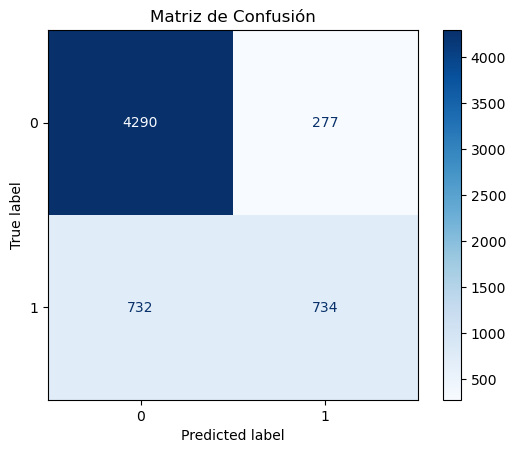

In [151]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

confusion_matrix_result = confusion_matrix(y_test, y_pred)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix_result)
print(classification_report(y_test, y_pred))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_result)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión")
plt.show()

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_pred = model.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
confusion_matrix_result = confusion_matrix(y_test, y_pred.round())
print("CM:\n", confusion_matrix_result)

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_result)
disp.plot(cmap=plt.cm.Blues) # Puedes usar otros mapas de color
plt.title("Matriz de Confusión")
plt.show()

## 9. Evaluación del modelo
